# **Classification**

### **MNIST Dataset Classification**

In [1]:
from sklearn.datasets import fetch_openml
import matplotlib
import matplotlib.pyplot as plt

mnist = fetch_openml("mnist_784", version=1, as_frame=False)


In [2]:
X, y = mnist.data, mnist.target
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


```
%matplotlib inline
```

What %matplotlib inline Does

It tells Jupyter:

 “Render all matplotlib figures inside the notebook.”

So plots appear immediately below the cell.

In [3]:
print(matplotlib.colormaps)

ColormapRegistry; available colormaps:
'magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 

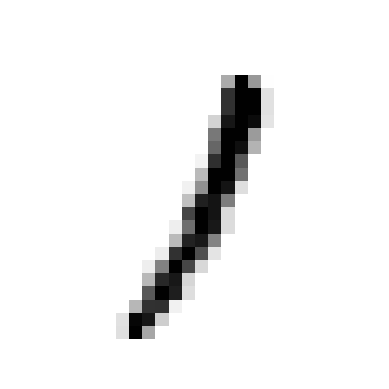

In [4]:
some_digit = X[99]
some_digit_image = some_digit.reshape(28, 28)
# matplotlib.cm             cm means color-map

%matplotlib inline
plt.imshow(some_digit_image, cmap=matplotlib.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show()

In [5]:
y = y.astype(int)

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train: ", X_train.shape)
print("X_test: ",X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ",y_test.shape)

X_train:  (56000, 784)
X_test:  (14000, 784)
y_train: (56000,)
y_test:  (14000,)


# **Training a Binary Classifier**

In [7]:
y_train_1 = (y_train == 1)
y_test_1 = (y_test == 1)

In [8]:
import numpy as np
print(type(y[0]))
print(np.unique(y))

<class 'numpy.int64'>
[0 1 2 3 4 5 6 7 8 9]


In [9]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42, n_jobs=-1)
sgd_clf.fit(X_train, y_train_1)


SGDClassifier(n_jobs=-1, random_state=42)

In [10]:
sgd_clf.predict([some_digit])

array([ True])

# **Performance Measures**

### **Measuring Accuracy Using Cross-Validation**

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skf = StratifiedKFold(n_splits=3)

for train_index, test_index in skf.split(X_train, y_train_1):

  sdg_clone = clone(sgd_clf)
  X_train_folds = X_train[train_index]
  y_train_folds = (y_train_1[train_index])

  X_test_fold = X_train[test_index]
  y_test_fold = (y_train_1[test_index])

  sdg_clone.fit(X_train_folds, y_train_folds)
  y_pred = sdg_clone.predict(X_test_fold)
  n_correct = sum(y_pred == y_test_fold)

  print(n_correct / len(y_pred))


0.9907858788235925
0.9885894894734023
0.9886424515161256


In [12]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_1, cv=3, scoring='accuracy')

array([0.99078588, 0.98858949, 0.98864245])

**dummy classifier**

In [13]:
from sklearn.base import BaseEstimator, TransformerMixin

class Never1Classifier(BaseEstimator):
  def fit(self, X, y=None):
    pass
  def predict(self, X):
    return np.zeros((len(X), 1), dtype=bool)


In [14]:
n5c = Never1Classifier()
cross_val_score(n5c, X_train, y_train_1, cv=3, scoring="accuracy")

array([0.88894841, 0.88766272, 0.88712097])

```
Why this is misleading

Suppose there are 1000 images:

910 are not 5
90 are 5

Your classifier predicts not 5 for all 1000.

Then:

it gets all 910 non-5 images correct
it gets all 90 five-images wrong
```


```
This example teaches an important machine learning lesson:

Accuracy alone is not enough for imbalanced classification.

For this problem, better metrics are:

precision
recall
F1 score
confusion matrix
```


# **Confusion Matrix**

In [15]:
from sklearn.model_selection import cross_val_predict

y_train_pred =  cross_val_predict(sgd_clf, X_train, y_train_1, cv=3, n_jobs=-1)


In [16]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_1, y_train_pred)


array([[49381,   342],
       [  255,  6022]])

In [19]:
from sklearn.metrics import precision_score, recall_score

print(precision_score(y_train_1, y_train_pred))

print(recall_score(y_train_1, y_train_pred))

0.9462602137020741
0.9593754978492911


In [21]:
from sklearn.metrics import f1_score

print(f1_score(y_train_1, y_train_pred))

0.9527727236769243


# **Precision/Recall Tradeoff**
```
Imagine a Security Guard

Suppose a guard checks people entering a building.

The guard must detect:

criminals = Positive class
innocent people = Negative class

The guard uses a confidence score.

STRICT Guard

The guard says:

“I will only arrest someone if I am VERY sure.”

This is like using a HIGH threshold.

Example:

threshold = 30000

Result:

very few innocent people arrested
but many criminals escape
Metrics
Precision becomes HIGH

Because:

when guard says “criminal”
he is usually correct
Recall becomes LOW

Because:

many real criminals were missed
RELAXED Guard

The guard says:

“I will arrest anyone slightly suspicious.”

This is LOW threshold.

Example:

threshold = -10000

Result:

catches almost all criminals
but many innocent people arrested
Metrics
Recall becomes HIGH

Because:

most real criminals caught
Precision becomes LOW

Because:

many false alarms
THIS IS THE TRADEOFF

You usually cannot maximize BOTH simultaneously.

Increasing one often decreases the other.
```

## **Decision Function:**

In [37]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2542.70735601])

if the confidence is greater than threshold then classify it as a true

```
y_pred = (sgd_clf.decision_function([some_digit]) > threshold)
```

In [46]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False, False, False, ...,  True, False, False])

In [50]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_1, cv=3,
method="decision_function")

In [48]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_train_1, y_scores)
# Internally It Does predict = (y_scores > threshold) for many threshold


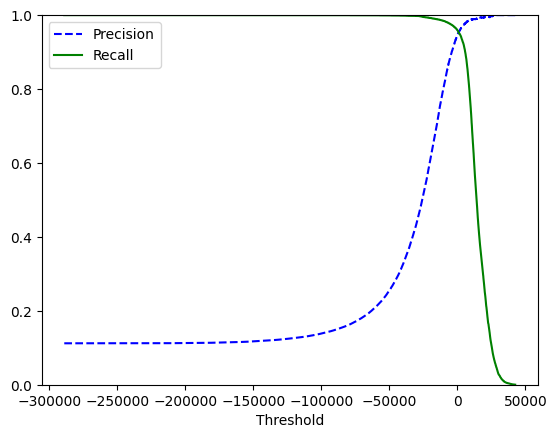

In [49]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds=0):
  plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
  plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
  plt.xlabel("Threshold")
  plt.legend(loc='upper left')
  plt.ylim([0,1])
  plt.xlim([-40000,45000])

plot_precision_recall_vs_threshold(precision, recall, thresholds)
plt.show()

### **Plot Precision vs Recall**

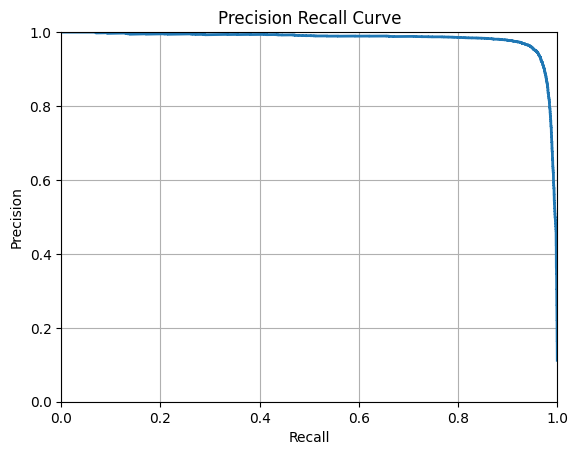

In [65]:
plt.plot(recall, precision, linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.xlim([0,1])
plt.ylim([0,1])

plt.grid(True)

plt.show()

### **LOWER THRESHOLD TO INCREASE RECALL**

In [66]:
custom_threshold = -10000

y_train_pred_high_recall = (y_scores > custom_threshold)

print("\nLOWER THRESHOLD RESULTS")
print("Threshold:", custom_threshold)

print("Precision:", precision_score(y_train_1, y_train_pred_high_recall))

print("Recall:", recall_score(y_train_1, y_train_pred_high_recall))



LOWER THRESHOLD RESULTS
Threshold: -10000
Precision: 0.8068434112576727
Recall: 0.9842281344591365


### **HIGHER THRESHOLD TO INCREASE PRECISION**

In [67]:
custom_threshold = 10000

y_train_pred_high_precision = (y_scores > custom_threshold)

print("HIGHER THRESHOLD RESULTS")
print("Threshold:", custom_threshold)

print("Precision:", precision_score(y_train_1, y_train_pred_high_precision))

print("Recall:", recall_score(y_train_1, y_train_pred_high_recall))


HIGHER THRESHOLD RESULTS
Threshold: 10000
Precision: 0.9876438005965061
Recall: 0.9842281344591365


# **The ROC Curve**